# External Noisy Data Without Initial Conditions
---
In this experiment, a PINN was trained using sparse external data (30 points per trajectory) corrupted with (20%) noise. ***Unlike previous experiments, the network was not provided with the initial conditions*** and only had access to the governing differential equations and the noisy observations.

To balance the contributions of the physics and data losses during training, a trainable scaling parameter $C$ was introduced. The PDE residual terms were defined according to $\frac{1}{C^2}\mathrm{Res}_{\mathrm{PDE}}.$

At the beginning of training, the PDE residuals typically generate large gradients and therefore strongly influence the optimization process. As training progresses, the trainable parameter (C) increases, effectively reducing the contribution of the PDE terms and allowing the network to better fit the noisy observational data.

**Key Features**

* External noisy data generated from Lagrange orbits.
* No initial conditions were provided to the network.
* Output-layer biases were initialized to different values to avoid singularities arising from symmetric initial predictions.
* A trainable scaling parameter was introduced to gradually reduce the influence of large PDE gradients during training.

**Important Observation**

Although no initial conditions were provided, the PINN reconstructs a solution in which the three bodies form an approximately equilateral triangle. This suggests that the governing equations and the noisy observations contain enough information to recover the geometric structure of the Lagrange orbit.






In [1]:
import os
os.environ["DDE_BACKEND"] = "tensorflow"

In [ ]:
!pip install deepxde

In [ ]:
!pip install tensorflow tf_keras matplotlib numpy scipy

## IMPORTS

In [ ]:
import deepxde as dde
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
from numpy.linalg import norm

# Training

In [ ]:
dde.config.set_default_float("float64")

seed=137
np.random.seed(seed)
tf.random.set_seed(seed)
dde.config.set_random_seed(seed)

# ============================================================
# Constants
# ============================================================
scale = 2
G = 1.0
m = [1.0, 1.0, 1.0]
periods=1
C = dde.Variable(3,dtype="float64")
endTime =periods * (4 / scale**3)


num_domain = 64
num_boundary = 12
num_test = 100


layer_size = [1] + [64]*3 + [6]
activation = "tanh"
initializer = "Glorot uniform" #"Glorot uniform" #"He normal" #

iterations =150000
learning_rate = 1e-4
loss_weights=[0.1]*6+[10]*6
#optimizer=tf.keras.optimizers.AdamW(learning_rate=0.0001,weight_decay=0.0004)


eps = 1e-9   #softening factor for gravity low

# ============================================================
# Initial Conditions
# ============================================================
omega = 0.3

x1_0, y1_0 = -1.0/scale**2, 0.0/scale**2
x2_0, y2_0 =  1.0/scale**2, 0.0/scale**2
x3_0, y3_0 =  0.0/scale**2, np.sqrt(3)/scale**2

vx1_0, vy1_0 = (-np.sqrt(3)/3)*omega*scale, 1*omega*scale
vx2_0, vy2_0 = (-np.sqrt(3)/3)*omega*scale, -1*omega*scale
vx3_0, vy3_0 = (2*np.sqrt(3)/3)*omega*scale, 0

y0 = np.array([x1_0,y1_0,x2_0,y2_0,x3_0,y3_0])
v0 = np.array([vx1_0,vy1_0,vx2_0,vy2_0,vx3_0,vy3_0])

y0_tf = tf.constant(y0)
v0_tf = tf.constant(v0)

# ============================================================
# NUMERICAL SOLUTION (for synthetic measurements)
# ============================================================

def three_body_numeric(t, y):

    x1,y1,vx1,vy1,x2,y2,vx2,vy2,x3,y3,vx3,vy3 = y

    r12 = np.sqrt((x1-x2)**2 + (y1-y2)**2 )+eps
    r13 = np.sqrt((x1-x3)**2 + (y1-y3)**2 )+eps
    r23 = np.sqrt((x2-x3)**2 + (y2-y3)**2 )+eps

    ax1 = G*(m[1]*(x2-x1)/r12**3 + m[2]*(x3-x1)/r13**3)
    ay1 = G*(m[1]*(y2-y1)/r12**3 + m[2]*(y3-y1)/r13**3)

    ax2 = G*(m[0]*(x1-x2)/r12**3 + m[2]*(x3-x2)/r23**3)
    ay2 = G*(m[0]*(y1-y2)/r12**3 + m[2]*(y3-y2)/r23**3)

    ax3 = G*(m[0]*(x1-x3)/r13**3 + m[1]*(x2-x3)/r23**3)
    ay3 = G*(m[0]*(y1-y3)/r13**3 + m[1]*(y2-y3)/r23**3)

    return [vx1,vy1,ax1,ay1,
            vx2,vy2,ax2,ay2,
            vx3,vy3,ax3,ay3]


t_span = (0,endTime)
t_eval = np.linspace(0,endTime,5000)

y0_full = [
x1_0,y1_0,vx1_0,vy1_0,
x2_0,y2_0,vx2_0,vy2_0,
x3_0,y3_0,vx3_0,vy3_0
]

sol = solve_ivp(three_body_numeric,t_span,y0_full,
                t_eval=t_eval,rtol=1e-10,atol=1e-12)

x1_n,y1_n = sol.y[0],sol.y[1]
x2_n,y2_n = sol.y[4],sol.y[5]
x3_n,y3_n = sol.y[8],sol.y[9]

# ============================================================
# SYNTHETIC NOISY MEASUREMENTS
# ============================================================

num_obs = 30
noise_level = 0.1

idx = np.sort(np.random.choice(len(t_eval),num_obs,replace=False))

t_obs = t_eval[idx][:,None]

y_obs_true = np.vstack([
x1_n[idx],y1_n[idx],
x2_n[idx],y2_n[idx],
x3_n[idx],y3_n[idx]
]).T

noise = noise_level*np.std(y_obs_true,axis=0)*np.random.randn(*y_obs_true.shape)

y_obs = y_obs_true + noise

# ============================================================
# PINN PDE
# ============================================================

def three_body_ode_second(t,y):

    x1,y1,x2,y2,x3,y3 = [y[:,i:i+1] for i in range(6)]

    r12 = tf.sqrt((x1-x2)**2 + (y1-y2)**2)+eps
    r13 = tf.sqrt((x1-x3)**2 + (y1-y3)**2)+eps
    r23 = tf.sqrt((x2-x3)**2 + (y2-y3)**2)+eps

    ax1 = G*(m[1]*(x2-x1)/r12**3 + m[2]*(x3-x1)/r13**3)
    ay1 = G*(m[1]*(y2-y1)/r12**3 + m[2]*(y3-y1)/r13**3)

    ax2 = G*(m[0]*(x1-x2)/r12**3 + m[2]*(x3-x2)/r23**3)
    ay2 = G*(m[0]*(y1-y2)/r12**3 + m[2]*(y3-y2)/r23**3)

    ax3 = G*(m[0]*(x1-x3)/r13**3 + m[1]*(x2-x3)/r23**3)
    ay3 = G*(m[0]*(y1-y3)/r13**3 + m[1]*(y2-y3)/r23**3)

    x1_tt = dde.grad.hessian(y,t,component=0,i=0,j=0)
    y1_tt = dde.grad.hessian(y,t,component=1,i=0,j=0)
    x2_tt = dde.grad.hessian(y,t,component=2,i=0,j=0)
    y2_tt = dde.grad.hessian(y,t,component=3,i=0,j=0)
    x3_tt = dde.grad.hessian(y,t,component=4,i=0,j=0)
    y3_tt = dde.grad.hessian(y,t,component=5,i=0,j=0)

    return [
    (1/C**2)*(x1_tt-ax1),
    (1/C**2)*(y1_tt-ay1),
    (1/C**2)*(x2_tt-ax2),
    (1/C**2)*(y2_tt-ay2),
    (1/C**2)*(x3_tt-ax3),
    (1/C**2)*(y3_tt-ay3)
    ]

# ============================================================
# Geometry
# ============================================================

geom = dde.geometry.TimeDomain(0,endTime)

# observation constraints
observe_x1 = dde.PointSetBC(t_obs,y_obs[:,0:1],component=0)
observe_y1 = dde.PointSetBC(t_obs,y_obs[:,1:2],component=1)
observe_x2 = dde.PointSetBC(t_obs,y_obs[:,2:3],component=2)
observe_y2 = dde.PointSetBC(t_obs,y_obs[:,3:4],component=3)
observe_x3 = dde.PointSetBC(t_obs,y_obs[:,4:5],component=4)
observe_y3 = dde.PointSetBC(t_obs,y_obs[:,5:6],component=5)

data = dde.data.PDE(
geom,
three_body_ode_second,
[ observe_x1,observe_y1,observe_x2,observe_y2,observe_x3,observe_y3],
num_domain=num_domain,
num_boundary=num_boundary,
num_test=num_test
)

# ============================================================
# NETWORK
# ============================================================

net = dde.nn.FNN(layer_size,activation,initializer)


model = dde.Model(data,net)

#model.compile(optimizer=optimizer)
model.compile("adam",lr=learning_rate,loss_weights=loss_weights, external_trainable_variables=C)

###############################################################
# Change bias in last layer to avoid xero outputs at t=0
###############################################################
model.predict([[0.0]])   #dummy presict to create model.. tensorflow behaviour
# modify bias
last_layer=3
model.net.summary()
last_layer = model.net.layers[last_layer]   # dense_3
w, b = last_layer.get_weights()
print("old bias:", b)
b = np.array([-0.3, -0.2, 0, 0, 0.1, 0.4])   # weight separation...
last_layer.set_weights([w, b])
print("new bias:", b)
##############################################################
##############################################################


losshistory,train_state = model.train(iterations=iterations)

#model.compile("L-BFGS")
#losshistory,train_state = model.train()

#Plots -Results

Saving loss history to /content/loss.dat ...
Saving training data to /content/train.dat ...
Saving test data to /content/test.dat ...


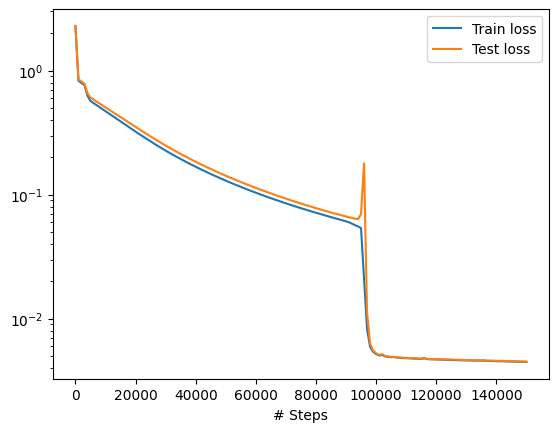

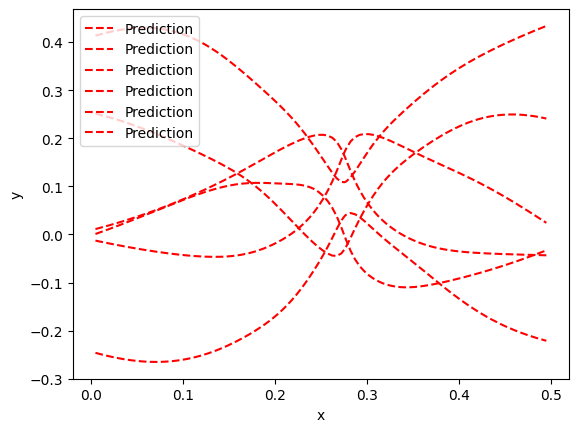

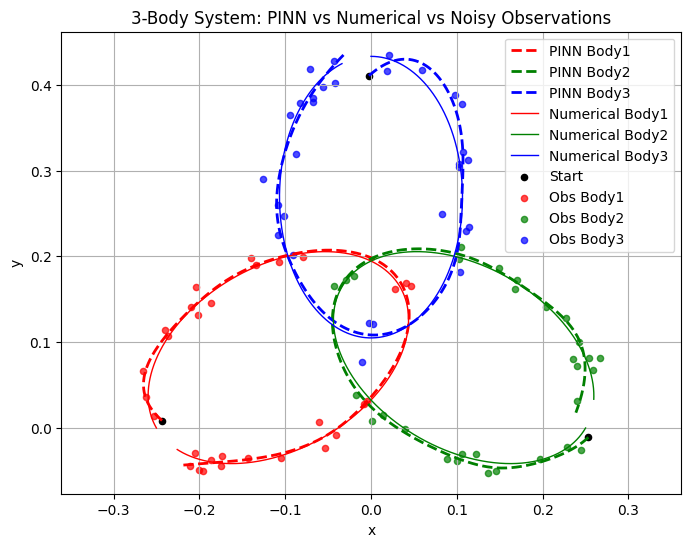

length-12  0.49715194410876123
length-13  0.46853223671944555
length-23  0.49282886440256274
Trainable Variable C=  <tf.Variable 'Variable:0' shape=() dtype=float64, numpy=16.78470194160471>

--- L2 Relative Errors ---
Body 1 x error: 2.29e-02
Body 1 y error: 4.43e-02
Body 2 x error: 2.77e-02
Body 2 y error: 5.27e-02
Body 3 x error: 4.71e-02
Body 3 y error: 2.60e-02


In [6]:
dde.saveplot(losshistory, train_state, issave=True, isplot=True)


# ============================================================
# PINN PREDICTION
# ============================================================

t_test = np.linspace(0,endTime,5000)[:,None]

y_pred = model.predict(t_test)

x1,y1 = y_pred[:,0],y_pred[:,1]
x2,y2 = y_pred[:,2],y_pred[:,3]
x3,y3 = y_pred[:,4],y_pred[:,5]

# ============================================================
# PLOTS
# ============================================================

plt.figure(figsize=(8,6))

plt.plot(x1,y1,'r--',lw=2,label="PINN Body1")
plt.plot(x2,y2,'g--',lw=2,label="PINN Body2")
plt.plot(x3,y3,'b--',lw=2,label="PINN Body3")

plt.plot(x1_n,y1_n,'r-',lw=1,label="Numerical Body1")
plt.plot(x2_n,y2_n,'g-',lw=1,label="Numerical Body2")
plt.plot(x3_n,y3_n,'b-',lw=1,label="Numerical Body3")

#starting points
plt.scatter([x1[0], x2[0], x3[0]],
            [y1[0], y2[0], y3[0]],
            color='k', marker='o', s=20, label='Start')

# noisy measurements
plt.scatter(y_obs[:,0],y_obs[:,1],c='red',s=20,alpha=0.7,label="Obs Body1")
plt.scatter(y_obs[:,2],y_obs[:,3],c='green',s=20,alpha=0.7,label="Obs Body2")
plt.scatter(y_obs[:,4],y_obs[:,5],c='blue',s=20,alpha=0.7,label="Obs Body3")

plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.axis("equal")

plt.title("3-Body System: PINN vs Numerical vs Noisy Observations")

plt.show()


#============================================
# DISTANCE OF INITAL POTITIONS
#=============================================

len12=np.sqrt((x1[0]-x2[0])**2 +(y1[0]-y2[0])**2 )
len13=np.sqrt((x1[0]-x3[0])**2 +(y1[0]-y3[0])**2 )
len23=np.sqrt((x2[0]-x3[0])**2 +(y2[0]-y3[0])**2 )
print("length-12 ",len12)
print("length-13 ",len13)
print("length-23 ",len23)

print("Trainable Variable C= ",C)


# ============================================================
# Optional: Compute relative L2 errors
# ============================================================
interp_x1 = interp1d(t_eval, x1_n, kind='cubic')
interp_y1 = interp1d(t_eval, y1_n, kind='cubic')
interp_x2 = interp1d(t_eval, x2_n, kind='cubic')
interp_y2 = interp1d(t_eval, y2_n, kind='cubic')
interp_x3 = interp1d(t_eval, x3_n, kind='cubic')
interp_y3 = interp1d(t_eval, y3_n, kind='cubic')

x1_err = norm(x1 - interp_x1(t_test[:,0])) / norm(interp_x1(t_test[:,0]))
y1_err = norm(y1 - interp_y1(t_test[:,0])) / norm(interp_y1(t_test[:,0]))
x2_err = norm(x2 - interp_x2(t_test[:,0])) / norm(interp_x2(t_test[:,0]))
y2_err = norm(y2 - interp_y2(t_test[:,0])) / norm(interp_y2(t_test[:,0]))
x3_err = norm(x3 - interp_x3(t_test[:,0])) / norm(interp_x3(t_test[:,0]))
y3_err = norm(y3 - interp_y3(t_test[:,0])) / norm(interp_y3(t_test[:,0]))

print("\n--- L2 Relative Errors ---")
print(f"Body 1 x error: {x1_err:.2e}")
print(f"Body 1 y error: {y1_err:.2e}")
print(f"Body 2 x error: {x2_err:.2e}")
print(f"Body 2 y error: {y2_err:.2e}")
print(f"Body 3 x error: {x3_err:.2e}")
print(f"Body 3 y error: {y3_err:.2e}")